     Supplier       Site  Deliveries  Deliveries on time  Purchase value  \
0      Nestle  Amsterdam          22                  21           23078   
1      Nestle  Amsterdam          22                  22           22550   
2      Nestle  Amsterdam          24                  22           30456   
3      Nestle  Amsterdam          25                  24           26600   
4      Nestle  Amsterdam          26                  26           34190   
..        ...        ...         ...                 ...             ...   
115  Unilever    Utrecht          20                  20           19940   
116  Unilever    Utrecht          21                  20           21000   
117  Unilever    Utrecht          22                  20           23276   
118  Unilever    Utrecht          22                  22           24178   
119  Unilever    Utrecht          23                  21           26680   

        Month  Year  
0        June  2023  
1    February  2023  
2     January  2023  

<Figure size 1200x600 with 0 Axes>

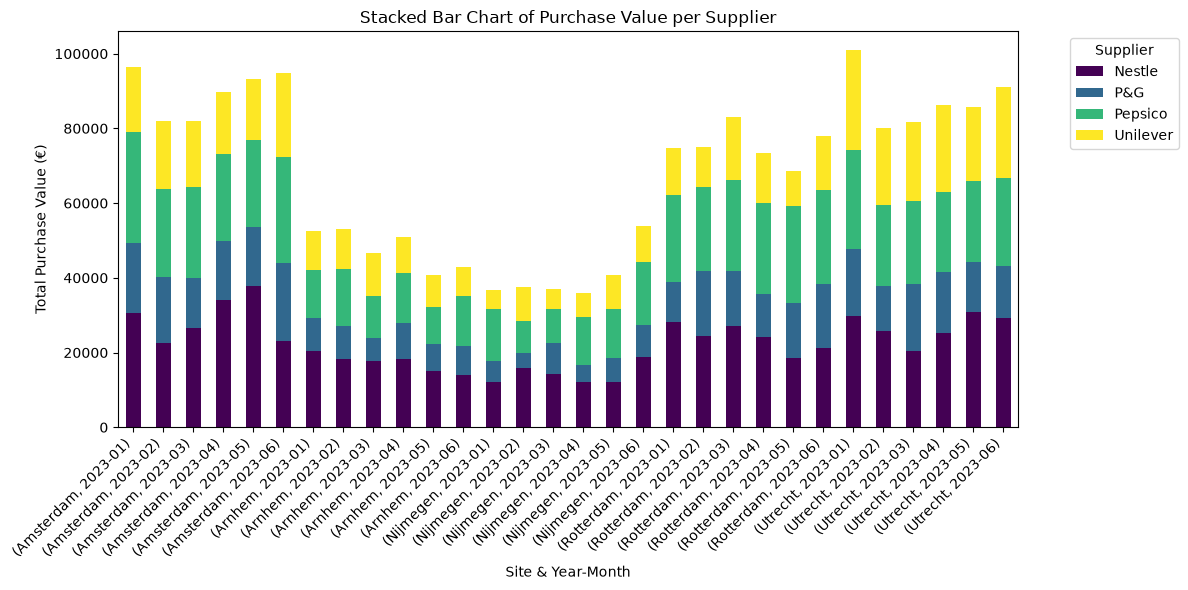

In [1]:
# -*- coding: utf-8 -*-
"""
Created on Wed Sep  6 13:09:57 2023

@author: jbrweelden
"""

import pandas as pd
import matplotlib.pyplot as plt

# Import data and adjust formatting
df = pd.read_csv('Week 2.csv')
print(df)

# Combine 'Month' and 'Year' columns into a single 'Date' column with explicit format
df['Date'] = pd.to_datetime(df['Month'] + ' ' + df['Year'].astype(str), format='%B %Y', errors='coerce')

# Check for any NaT (not-a-time) values, which indicate parsing issues
if df['Date'].isna().any():
    print("Warning: Some dates could not be parsed. Check the 'Month' and 'Year' columns.")
    print(df[df['Date'].isna()])  # Print problematic rows for debugging

# Format the 'Date' column to display only year and month
df['Year-Month'] = df['Date'].dt.strftime('%Y-%m')

# Drop the 'Date' column
df = df.drop(columns=['Date'])

# Ensure 'Purchase value' is numeric
df['Purchase value'] = pd.to_numeric(df['Purchase value'], errors='coerce')

# Pivot the DataFrame for a stacked bar chart
pivot_df = df.pivot_table(index=['Site', 'Year-Month'], columns='Supplier', values='Purchase value', aggfunc='sum')

# Print the pivoted DataFrame for debugging
print("\nPivoted DataFrame:")
print(pivot_df)

# Reset index for better plotting
pivot_df = pivot_df.reset_index()

# Plot using Matplotlib
plt.figure(figsize=(12, 6))
pivot_df.set_index(['Site', 'Year-Month']).plot(kind='bar', stacked=True, colormap='viridis', figsize=(12, 6))

# Improve plot aesthetics
plt.xlabel("Site & Year-Month")
plt.ylabel("Total Purchase Value (€)")
plt.title("Stacked Bar Chart of Purchase Value per Supplier")
plt.xticks(rotation=45, ha="right")  # Rotate x-axis labels for readability
plt.legend(title="Supplier", bbox_to_anchor=(1.05, 1), loc='upper left')  # Move legend outside

# Show the plot
plt.tight_layout()
plt.show()
